# From Raw EMG to Predicted Hand Kinematics -- Test9 Pipeline

Loads the actual trained/calibrated Test9 model and a real recording (no
reimplementation -- imports `Test9/backend.py` directly, the same
train/predict/finetune path the frontend uses) and builds seven figures:

1. Raw forearm EMG
2. The model pipeline (one window -> one prediction)
3. Predicted vs. true kinematics across one movement
4. The resulting hand pose (illustrative geometry)
5. **Continuous decoding proof** -- predicted vs. true over a longer stretch, including the model's weakest joints (J1, J2)
6. **R^2 by project stage** -- calibrated/within-subject vs. cross-subject, across all seven prior project stages
7. **Per-joint R^2** for the calibrated model -- why joint-averaged R^2 is reported instead of pooled

## Setup -- load the real trained model and a real recording

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch
from scipy.io import loadmat

# soft blue-grey background instead of plain white, for every figure in this notebook -- also
# applied to saved PNGs (savefig.facecolor), not just the inline display
plt.rcParams["figure.facecolor"] = "#eef2f8"
plt.rcParams["axes.facecolor"] = "#f8fafc"
plt.rcParams["savefig.facecolor"] = "#eef2f8"

TEST9 = os.path.join("..", "Test9")
sys.path.insert(0, TEST9)
import backend as b   # Test9's consolidated backend -- same Net/predict path the frontend uses

SUBJECT_FILE = "S13_E1_A1.mat"
data_path = os.path.join(TEST9, "data", SUBJECT_FILE)
ckpt_path = os.path.join(TEST9, f"EMG-KinNet_finetuned_{os.path.splitext(SUBJECT_FILE)[0]}.pt")

ds = b.DATASETS["db2"]
ck = b.torch.load(ckpt_path, map_location=b.dev, weights_only=False)
net = b.new_net(ds)
net.load_state_dict(ck["sd"]); net.eval()

m = loadmat(data_path)
restim = m["restimulus"].astype(int).ravel()
X, Y, M, warns = b.windows_from(ds, data_path)
pred = b.predict_batches(net, ds, ck, X, M)
win_restim = np.asarray([np.bincount(restim[s:s + b.WIN]).argmax()
                         for s in range(0, len(restim) - b.WIN, b.HOP)])[:len(X)]

emg, glove, mask, _ = b.load_emg_file(ds, data_path)
n_real = int(mask.sum())

JOINT_NAMES = [
    "Thumb rotation", "Thumb MCP", "Thumb IP", "Thumb-index abduction",
    "Index MCP", "Index PIP", "Index DIP", "Index-middle abduction",
    "Middle MCP", "Middle PIP", "Middle DIP", "Middle-ring abduction",
    "Ring MCP", "Ring PIP", "Ring DIP", "Ring-little abduction",
    "Little MCP", "Little PIP", "Little DIP",
    "Palm arch", "Wrist flexion/extension", "Wrist abduction/adduction",
]

# a representative real movement, used by Figures 1, 3, 4
target_restim = None
for mv in sorted(set(win_restim.tolist()) - {0}):
    idx = np.where(win_restim == mv)[0]
    if len(idx) >= 15:
        target_restim = mv
        break
idx = np.where(win_restim == target_restim)[0]
s0, s1 = idx[0], idx[-1]

print(f"Loaded {SUBJECT_FILE}: {len(X)} windows, {n_real} real EMG channels, checkpoint={os.path.basename(ckpt_path)}")
print(f"Representative movement: restimulus={target_restim}, windows {s0}-{s1} ({s1 - s0 + 1} windows)")

Loaded S13_E1_A1.mat: 9005 windows, 12 real EMG channels, checkpoint=EMG-KinNet_finetuned_S13_E1_A1.pt
Representative movement: restimulus=1, windows 34-541 (508 windows)


## Figure 1 -- Raw Forearm EMG
The raw input signal the model actually sees: 12-channel surface EMG for one real, labelled movement.

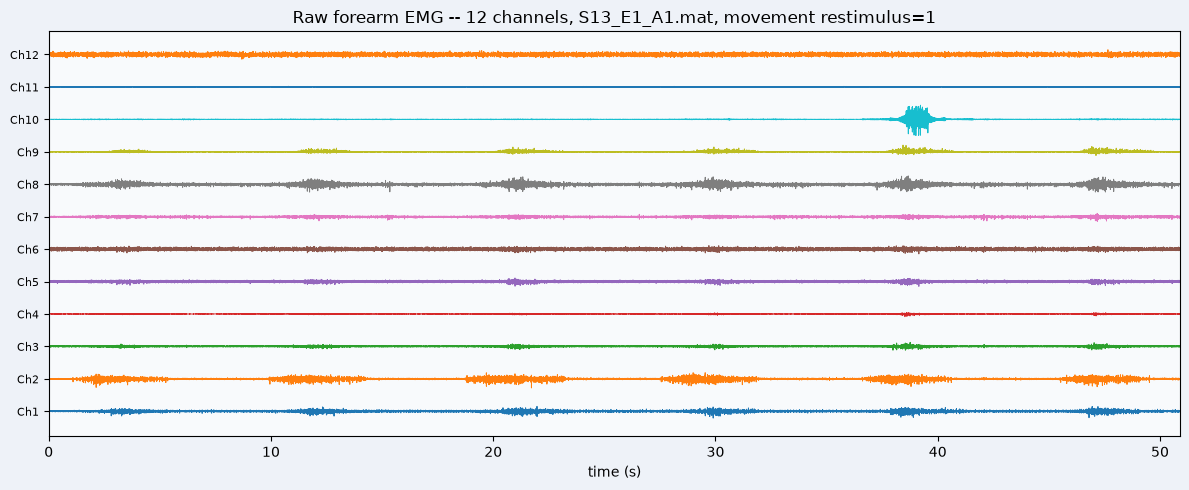

In [2]:
emg_t0, emg_t1 = s0 * b.HOP, s1 * b.HOP + b.WIN
emg_seg = emg[emg_t0:emg_t1, :n_real]
tt = np.arange(len(emg_seg)) / ds["fs"]

fig, ax = plt.subplots(figsize=(12, 5))
offset = np.max(np.abs(emg_seg)) * 2.0 + 1e-6
for c in range(emg_seg.shape[1]):
    ax.plot(tt, emg_seg[:, c] + c * offset, lw=0.7)
ax.set_yticks([c * offset for c in range(emg_seg.shape[1])])
ax.set_yticklabels([f"Ch{c+1}" for c in range(emg_seg.shape[1])], fontsize=8)
ax.set_xlabel("time (s)")
ax.set_title(f"Raw forearm EMG -- {n_real} channels, {SUBJECT_FILE}, movement restimulus={target_restim}")
ax.margins(x=0)
plt.tight_layout()
plt.savefig("fig1_raw_emg.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 -- The Model Pipeline
How ONE 200ms EMG window becomes ONE predicted kinematics vector (`Test9/backend.py`'s `Net`).

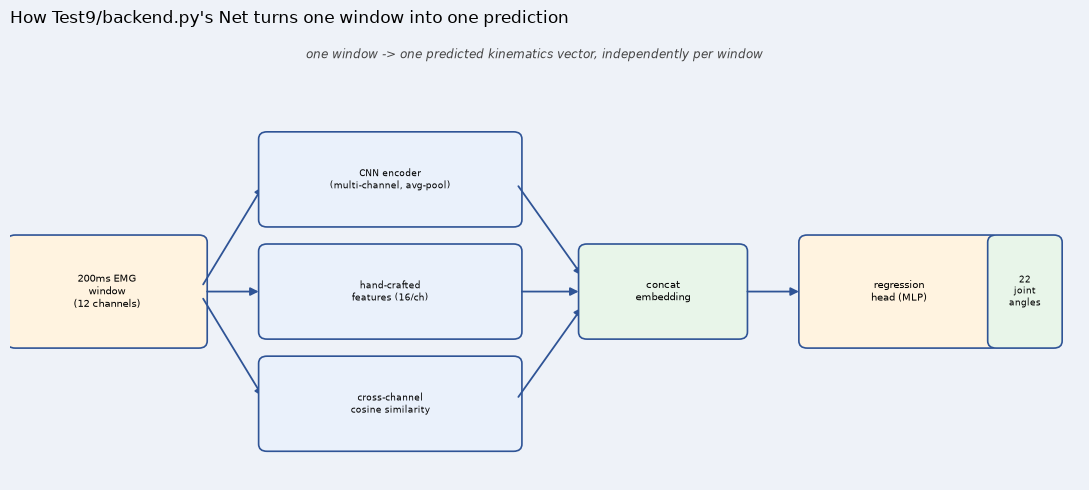

In [3]:
def pipeline_schematic(ax):
    ax.set_xlim(0, 10.2); ax.set_ylim(0, 5); ax.axis("off")

    def box(x, y, w, h, text, fc="#eaf1fb", fontsize=8):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                                    linewidth=1.2, edgecolor="#2F5496", facecolor=fc))
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)

    def arrow(x0, y0, x1, y1):
        ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>",
                                     mutation_scale=12, color="#2F5496", lw=1.3,
                                     shrinkA=6, shrinkB=6))

    ax.text(5.0, 4.7, "one window -> one predicted kinematics vector, independently per window",
           ha="center", fontsize=8.5, style="italic", color="#444")

    box(0.05, 1.55, 1.75, 1.1, "200ms EMG\nwindow\n(12 channels)", fc="#fff3e0", fontsize=7.5)
    arrow(1.8, 2.1, 2.45, 3.35)
    arrow(1.8, 2.1, 2.45, 2.1)
    arrow(1.8, 2.1, 2.45, 0.85)
    box(2.45, 2.9, 2.35, 0.9, "CNN encoder\n(multi-channel, avg-pool)", fontsize=6.8)
    box(2.45, 1.65, 2.35, 0.9, "hand-crafted\nfeatures (16/ch)", fontsize=6.8)
    box(2.45, 0.4, 2.35, 0.9, "cross-channel\ncosine similarity", fontsize=6.8)
    arrow(4.8, 3.35, 5.5, 2.2)
    arrow(4.8, 2.1, 5.5, 2.1)
    arrow(4.8, 0.85, 5.5, 2.0)
    box(5.5, 1.65, 1.45, 0.9, "concat\nembedding", fc="#e8f5e9", fontsize=7)
    arrow(6.95, 2.1, 7.6, 2.1)
    box(7.6, 1.55, 1.75, 1.1, "regression\nhead (MLP)", fc="#fff3e0", fontsize=7.5)
    arrow(9.35, 2.1, 9.75, 2.1)
    box(9.4, 1.55, 0.55, 1.1, "22\njoint\nangles", fc="#e8f5e9", fontsize=6.5)

fig, ax = plt.subplots(figsize=(11, 5))
pipeline_schematic(ax)
ax.set_title("How Test9/backend.py's Net turns one window into one prediction", fontsize=12, loc="left")
plt.tight_layout()
plt.savefig("fig2_pipeline_schematic.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 -- Predicted vs. True Kinematics Across One Movement
Four representative joints, over the same movement shown in Figure 1.

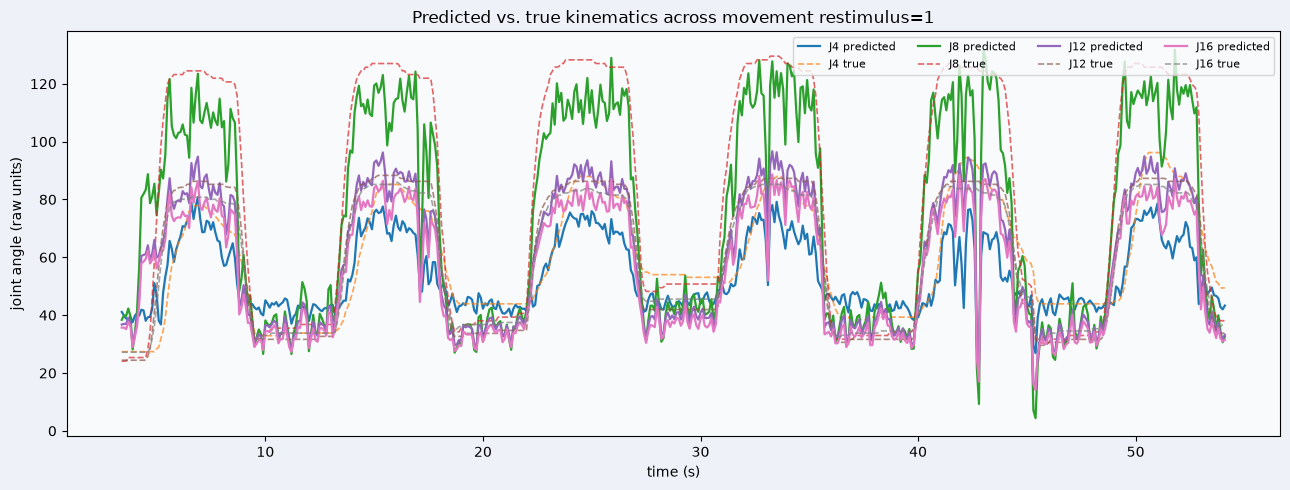

In [4]:
show_joints = [4, 8, 12, 16]   # Index/Middle/Ring/Little MCP -- clean, comparable-scale flexion joints
seg_idx = np.arange(s0, s1 + 1)
tt_w = seg_idx * b.HOP / ds["fs"]

fig, ax = plt.subplots(figsize=(13, 5))
for j in show_joints:
    ax.plot(tt_w, pred[seg_idx, j], lw=1.6, label=f"J{j} predicted")
    if Y is not None:
        ax.plot(tt_w, Y[seg_idx, j], lw=1.2, ls="--", alpha=0.7, label=f"J{j} true")
ax.set_xlabel("time (s)"); ax.set_ylabel("joint angle (raw units)")
ax.legend(fontsize=8, ncol=4, loc="upper right")
ax.set_title(f"Predicted vs. true kinematics across movement restimulus={target_restim}")
plt.tight_layout()
plt.savefig("fig3_predicted_vs_true_one_movement.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 4 -- Resulting Hand Pose
A simple 2D hand-skeleton rendering, predicted vs. true, at the movement's peak frame.
**Best-effort illustrative geometry only** -- joint segment lengths are generic anthropometric
figures, not measured for this subject or any specific device, and the CyberGlove channel-to-joint
mapping is the same unverified best-effort assignment used throughout this project.

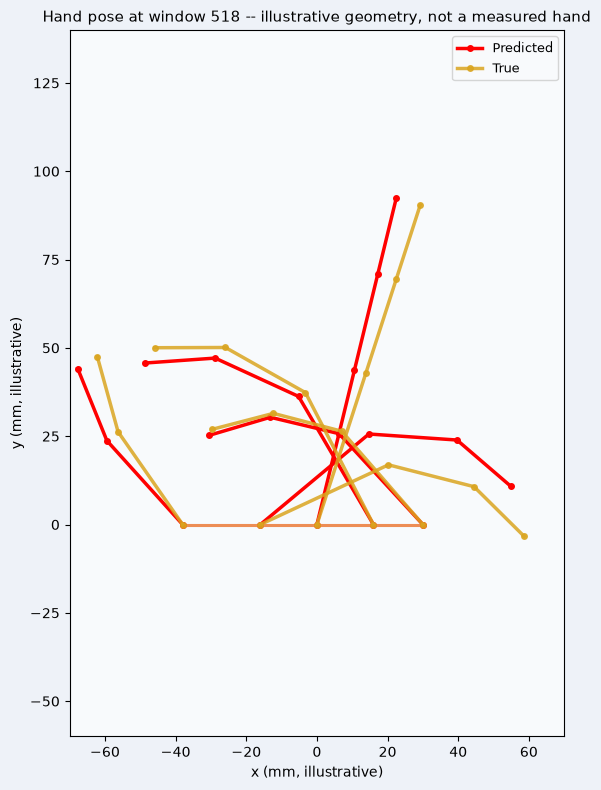

In [5]:
FINGER_JOINTS = {"Thumb": [1, 2], "Index": [4, 5, 6], "Middle": [8, 9, 10],
                 "Ring": [12, 13, 14], "Little": [16, 17, 18]}
FINGER_ABDUCTION_CH = {"Thumb": 3, "Index": 7, "Middle": 11, "Ring": 15, "Little": None}
FINGER_SEGMENT_MM = {"Thumb": (32, 22), "Index": (40, 25, 20), "Middle": (45, 28, 22),
                     "Ring": (42, 26, 20), "Little": (35, 20, 18)}
FINGER_BASE_X_MM = {"Thumb": -38, "Index": -16, "Middle": 0, "Ring": 16, "Little": 30}
FINGER_BASE_ANGLE_DEG = {"Thumb": -55, "Index": 0, "Middle": 0, "Ring": 0, "Little": 0}
MAX_FLEX_DEG, MAX_ABD_DEG = 45, 20   # per-JOINT cap -- fingers have up to 3 joints, so a 90 deg/joint
                                     # cap (as used elsewhere in this project) could curl a finger up
                                     # to 270 deg total (folding back past itself); 45/joint caps a
                                     # 3-joint finger at a realistic-looking ~135 deg of total curl

def normalize_channels(values, ref):
    lo, hi = np.percentile(ref, 1, axis=0), np.percentile(ref, 99, axis=0)
    span = np.where(hi - lo > 1e-6, hi - lo, 1.0)
    return np.clip((values - lo) / span, 0, 1)

def finger_chain_xy(norm, finger):
    """Each finger starts pointing away from the palm (straight up, or the thumb's own lean) and
    curls TOWARD the hand's centreline as its joints flex -- fingers left of centre curl right,
    fingers right of centre curl left, converging into a fist-like shape as flexion increases."""
    joints, lens = FINGER_JOINTS[finger], FINGER_SEGMENT_MM[finger]
    abd_ch = FINGER_ABDUCTION_CH.get(finger)
    base_x = FINGER_BASE_X_MM[finger]
    base_angle = np.radians(FINGER_BASE_ANGLE_DEG[finger])
    if abd_ch is not None:
        base_angle += np.radians((float(norm[abd_ch]) - 0.5) * 2 * MAX_ABD_DEG)
    side_sign = 1.0 if base_x < -2 else (-1.0 if base_x > 2 else 0.0)

    x, y = base_x, 0.0
    pts = [(x, y)]
    cum_flex = 0.0
    for j, length in zip(joints, lens):
        cum_flex += float(norm[j]) * np.radians(MAX_FLEX_DEG)
        dir_angle = base_angle + cum_flex * side_sign
        x += length * np.sin(dir_angle)
        y += length * np.cos(dir_angle)
        pts.append((x, y))
    return np.array(pts)

def draw_hand(ax, norm, color, label, alpha=1.0):
    for finger in FINGER_JOINTS:
        pts = finger_chain_xy(norm, finger)
        ax.plot(pts[:, 0], pts[:, 1], "-o", color=color, lw=2.5, ms=4, alpha=alpha,
                label=label if finger == "Middle" else None)
    order = ["Little", "Ring", "Middle", "Index", "Thumb"]
    palm_x = [FINGER_BASE_X_MM[f] for f in order]
    ax.plot(palm_x, [0] * len(order), "-", color=color, lw=2.2, alpha=alpha * 0.5)

fig, ax = plt.subplots(figsize=(7, 8))
ax.set_aspect("equal")
ref = Y if Y is not None else pred
seg_idx = np.arange(s0, s1 + 1)
peak_local = np.argmax(np.abs(pred[seg_idx, 8] - pred[seg_idx[0], 8]))
peak = seg_idx[peak_local]
norm_pred = normalize_channels(pred[peak], ref)
draw_hand(ax, norm_pred, "red", "Predicted")
if Y is not None:
    norm_true = normalize_channels(Y[peak], ref)
    draw_hand(ax, norm_true, "goldenrod", "True", alpha=0.85)
ax.set_xlim(-70, 70); ax.set_ylim(-60, 140)
ax.set_xlabel("x (mm, illustrative)"); ax.set_ylabel("y (mm, illustrative)")
ax.legend(fontsize=9, loc="upper right")
ax.set_title(f"Hand pose at window {peak} -- illustrative geometry, not a measured hand", fontsize=11)
plt.tight_layout()
plt.savefig("fig4_hand_pose.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 5 -- Continuous Decoding Proof (including J1, J2)

This is the proof the model actually works: continuous kinematics decoded from EMG over an
extended, multi-movement stretch of the recording -- not one cherry-picked clip. Includes two of
the model's **weakest** joints (J1 Thumb MCP, J2 Thumb IP) alongside two strong ones (J8, J16), so
this is an honest demonstration, not a best-case-only one.

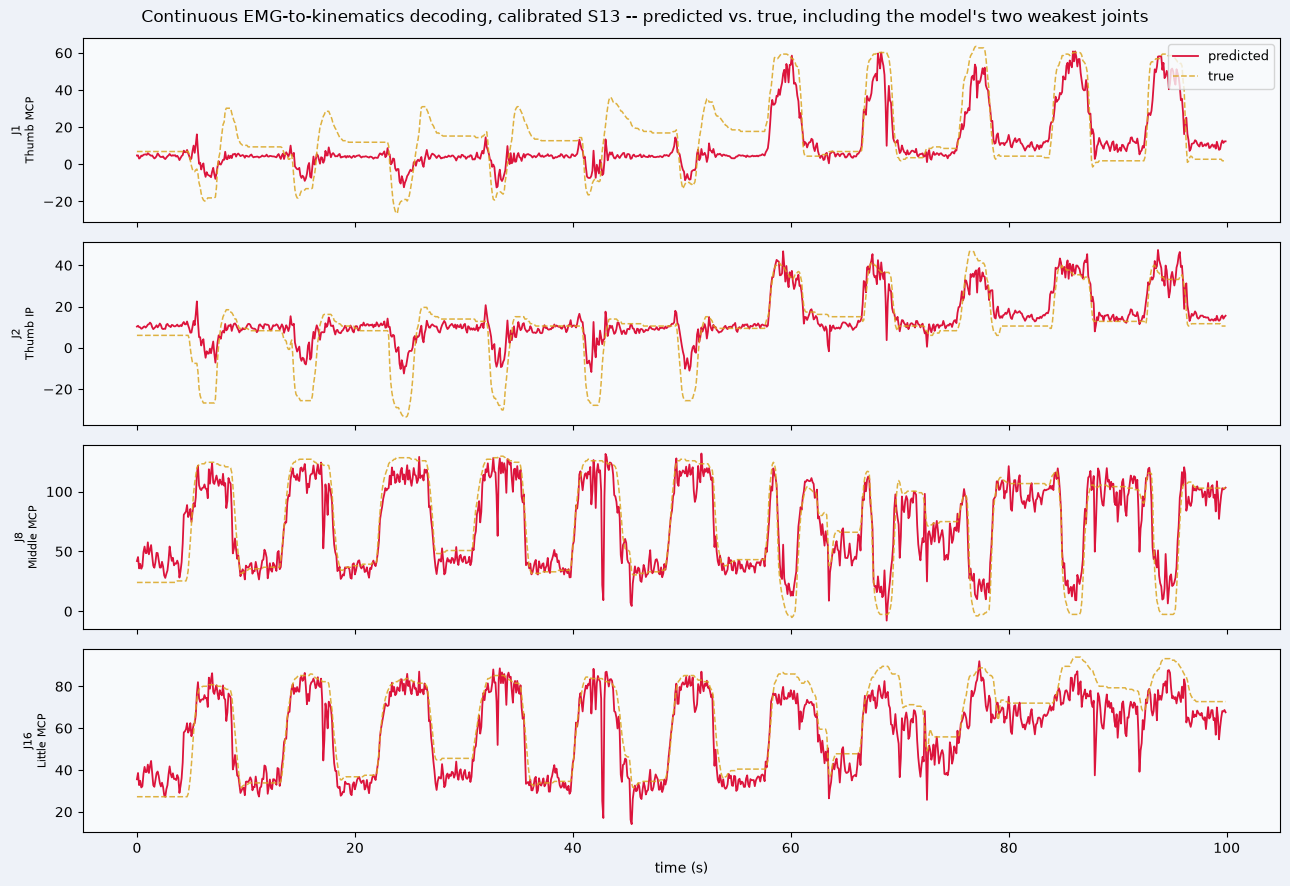

In [6]:
show_joints = [1, 2, 8, 16]   # Thumb MCP, Thumb IP (weak) + Middle MCP, Little MCP (strong)
t_start_s, t_end_s = 0, 100   # first ~100s of the recording -- spans several real movements
w_start = 0
w_end = min(len(pred), int(t_end_s * ds["fs"] / b.HOP))
seg = np.arange(w_start, w_end)
tt = seg * b.HOP / ds["fs"]

fig, axes = plt.subplots(len(show_joints), 1, figsize=(13, 9), sharex=True)
for ax, j in zip(axes, show_joints):
    ax.plot(tt, pred[seg, j], lw=1.3, color="crimson", label="predicted")
    ax.plot(tt, Y[seg, j], lw=1.1, color="goldenrod", ls="--", alpha=0.85, label="true")
    ax.set_ylabel(f"J{j}\n{JOINT_NAMES[j]}", fontsize=8)
axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"Continuous EMG-to-kinematics decoding, calibrated {SUBJECT_FILE.split(chr(95))[0]} -- "
           "predicted vs. true, including the model's two weakest joints", fontsize=12)
plt.tight_layout()
plt.savefig("fig5_continuous_decoding_proof.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 6 -- R^2 by Project Stage: Calibration Succeeds, Cross-Subject Fails

The intellectual core of the whole seven-stage project arc, in one image. Every value below is a
previously verified, real result from this project's own history (not recomputed here) --
within-subject/calibrated results are consistently positive; every zero-shot cross-subject attempt,
across three independent stages and several model families, is negative.

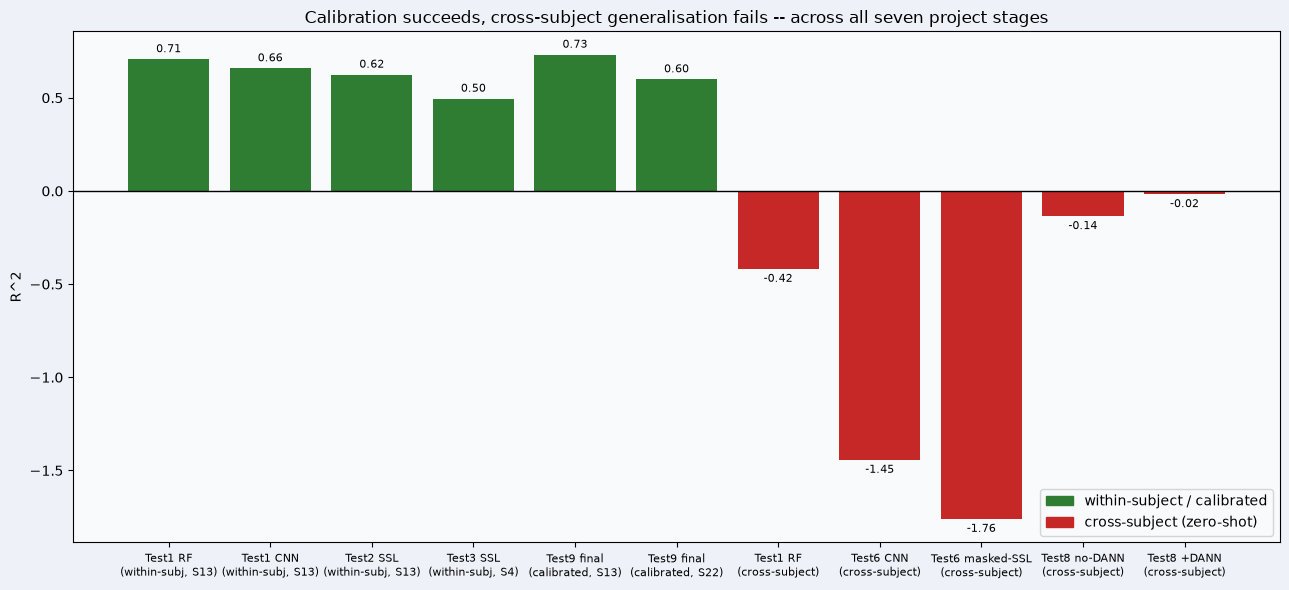

In [7]:
# (label, R^2, category) -- every value is a previously verified result from this project's own
# history (Test1 through Test9), not recomputed in this notebook.
stage_results = [
    ("Test1 RF\n(within-subj, S13)", 0.708, "calibrated"),
    ("Test1 CNN\n(within-subj, S13)", 0.659, "calibrated"),
    ("Test2 SSL\n(within-subj, S13)", 0.625, "calibrated"),
    ("Test3 SSL\n(within-subj, S4)", 0.496, "calibrated"),
    ("Test9 final\n(calibrated, S13)", 0.732, "calibrated"),
    ("Test9 final\n(calibrated, S22)", 0.600, "calibrated"),
    ("Test1 RF\n(cross-subject)", -0.42, "cross-subject"),
    ("Test6 CNN\n(cross-subject)", -1.445, "cross-subject"),
    ("Test6 masked-SSL\n(cross-subject)", -1.762, "cross-subject"),
    ("Test8 no-DANN\n(cross-subject)", -0.137, "cross-subject"),
    ("Test8 +DANN\n(cross-subject)", -0.019, "cross-subject"),
]
labels = [s[0] for s in stage_results]
values = [s[1] for s in stage_results]
colors = ["#2e7d32" if s[2] == "calibrated" else "#c62828" for s in stage_results]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(len(labels)), values, color=colors)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("R^2")
ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=3)
ax.legend(handles=[Patch(color="#2e7d32", label="within-subject / calibrated"),
                    Patch(color="#c62828", label="cross-subject (zero-shot)")], loc="lower right")
ax.set_title("Calibration succeeds, cross-subject generalisation fails -- across all seven project stages")
plt.tight_layout()
plt.savefig("fig6_r2_by_stage.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 7 -- Per-Joint R^2 for the Calibrated Model

Why this project reports joint-averaged (fair) R^2 rather than pooled R^2: J10's raw-value scale is
roughly 15x larger than most other joints, so a pooled R^2 mostly just measures how well J10 alone
is predicted. This figure shows exactly which joints the model predicts well and which it doesn't --
computed on the SAME leakage-safe held-out split `finetune()` itself uses, so the joint-averaged
value below reproduces the officially reported number exactly.

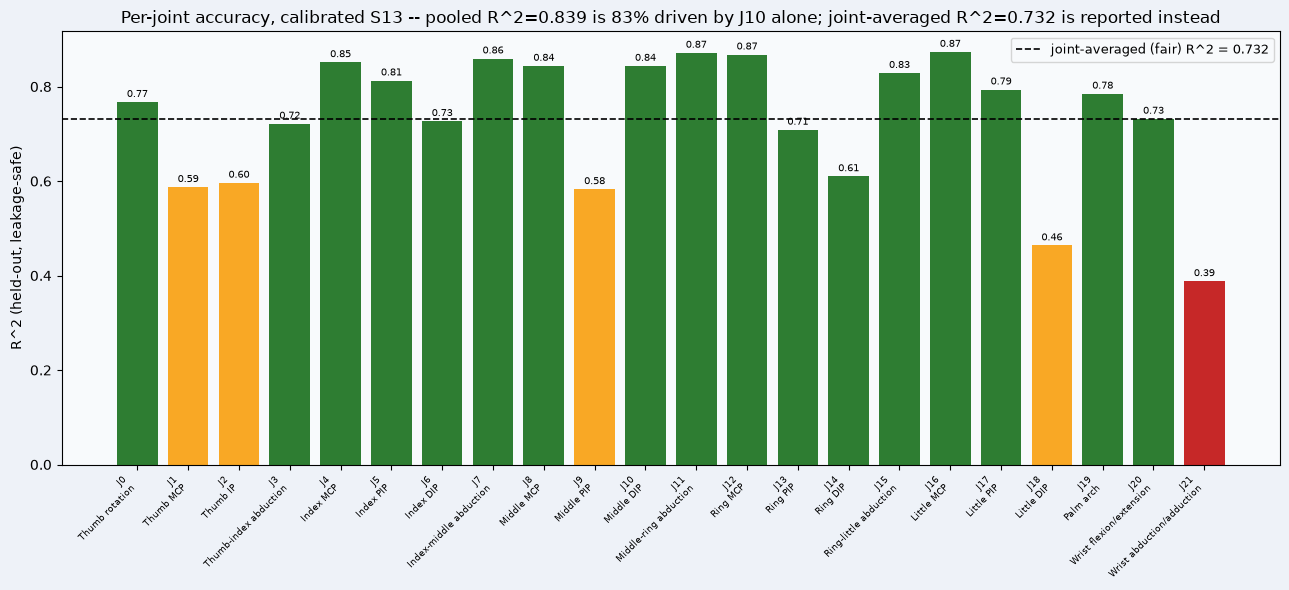

pooled R^2 = 0.839 (dominated 83% by J10)
joint-averaged (fair) R^2 = 0.732  <-- the honestly reported official number


In [8]:
rng = np.random.default_rng(0)
calib_idx, eval_idx = b.leakage_safe_split(len(X), 0.7, rng, gap=1)

pred_eval, Y_eval = pred[eval_idx], Y[eval_idx]
joint_ss_res = np.sum((pred_eval - Y_eval) ** 2, axis=0)
joint_ss_tot = np.sum((Y_eval - Y_eval.mean(0, keepdims=True)) ** 2, axis=0)
joint_r2 = 1 - joint_ss_res / joint_ss_tot
pooled_r2 = 1 - joint_ss_res.sum() / joint_ss_tot.sum()
fair_r2 = joint_r2.mean()
dominant = int(np.argmax(joint_ss_tot))
dominant_share = joint_ss_tot[dominant] / joint_ss_tot.sum()

colors = ["#2e7d32" if r >= 0.6 else ("#f9a825" if r >= 0.4 else "#c62828") for r in joint_r2]
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(22), joint_r2, color=colors)
ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)
ax.set_xticks(range(22))
ax.set_xticklabels([f"J{j}\n{JOINT_NAMES[j]}" for j in range(22)], fontsize=6.5, rotation=45, ha="right")
ax.axhline(fair_r2, color="black", ls="--", lw=1.2, label=f"joint-averaged (fair) R^2 = {fair_r2:.3f}")
ax.set_ylabel("R^2 (held-out, leakage-safe)")
ax.set_title(f"Per-joint accuracy, calibrated {SUBJECT_FILE.split(chr(95))[0]} -- pooled R^2={pooled_r2:.3f} is "
           f"{dominant_share*100:.0f}% driven by J{dominant} alone; joint-averaged R^2={fair_r2:.3f} is reported instead")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("fig7_per_joint_r2.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"pooled R^2 = {pooled_r2:.3f} (dominated {dominant_share*100:.0f}% by J{dominant})")
print(f"joint-averaged (fair) R^2 = {fair_r2:.3f}  <-- the honestly reported official number")

## Figure 8 -- EMG: Time Domain to Frequency Domain

The raw EMG signal in Figure 1 is a time-domain waveform. Part of what the "hand-crafted features"
branch in Figure 2 computes per channel is spectral, not temporal: mean power frequency, median
frequency, and five FFT-magnitude band sums (see `handcrafted_features()` /
`_channel_features()` in `backend.py`). This figure shows that conversion directly -- the same FFT,
on the same real EMG, for one analysis window -- so the frequency-domain features aren't just a
name in a list, they're a real, inspectable transform of the actual signal.

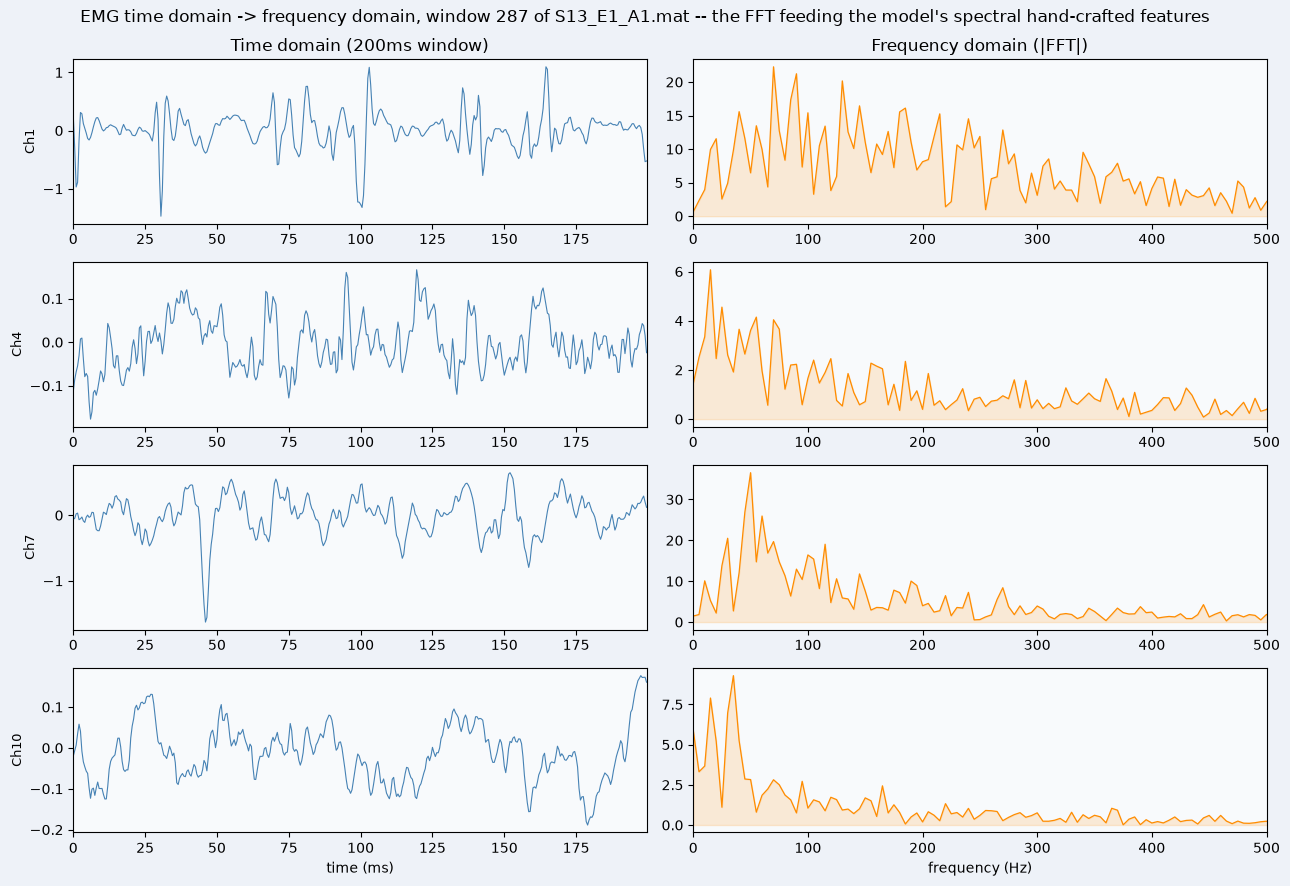

In [9]:
show_channels = [0, 3, 6, 9]   # a representative spread across the 12 real channels
win_idx = (s0 + s1) // 2       # a window from the middle of the representative movement -- likely
                               # active muscle contraction, not a quiet/rest window
x_window = X[win_idx]          # (MAX_CHANNELS, WIN) -- the exact per-file z-scored window the
                               # model itself sees, same array Figure 2's "200ms EMG window" box represents

freqs_hz = np.fft.rfftfreq(b.WIN, d=1.0 / ds["fs"])   # same np.fft.rfft used inside
                                                       # backend.py's _channel_features()
tt_win = np.arange(b.WIN) / ds["fs"] * 1000            # ms within the window

fig, axes = plt.subplots(len(show_channels), 2, figsize=(13, 9))
for row, ch in enumerate(show_channels):
    sig = x_window[ch]
    spec = np.abs(np.fft.rfft(sig))

    axes[row, 0].plot(tt_win, sig, lw=0.8, color="steelblue")
    axes[row, 0].set_ylabel(f"Ch{ch + 1}", fontsize=9)
    axes[row, 0].margins(x=0)
    if row == 0:
        axes[row, 0].set_title("Time domain (200ms window)")
    if row == len(show_channels) - 1:
        axes[row, 0].set_xlabel("time (ms)")

    axes[row, 1].plot(freqs_hz, spec, lw=0.9, color="darkorange")
    axes[row, 1].fill_between(freqs_hz, spec, alpha=0.15, color="darkorange")
    axes[row, 1].set_xlim(0, 500)   # sEMG power concentrates well under the 1000Hz Nyquist here
    axes[row, 1].margins(x=0)
    if row == 0:
        axes[row, 1].set_title("Frequency domain (|FFT|)")
    if row == len(show_channels) - 1:
        axes[row, 1].set_xlabel("frequency (Hz)")

fig.suptitle(f"EMG time domain -> frequency domain, window {win_idx} of {SUBJECT_FILE} -- the FFT "
           "feeding the model's spectral hand-crafted features", fontsize=12)
plt.tight_layout()
plt.savefig("fig8_time_to_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 9 -- The Cross-Channel Cosine-Similarity Matrix

Figure 2's pipeline shows three branches feeding the regression head; Figure 8 visualised the
spectral half of the hand-crafted branch, but the third branch -- cross-channel cosine similarity
(`channel_cosine_similarity()` in `backend.py`) -- has not been shown as real numbers yet. This is
that matrix, computed on the exact same window as Figure 8: pairwise cosine similarity between every
pair of channels' hand-crafted feature vectors, the ROCKET-paper-inspired feature verified (in the
Test8 investigation) to give a real accuracy gain on this dataset.

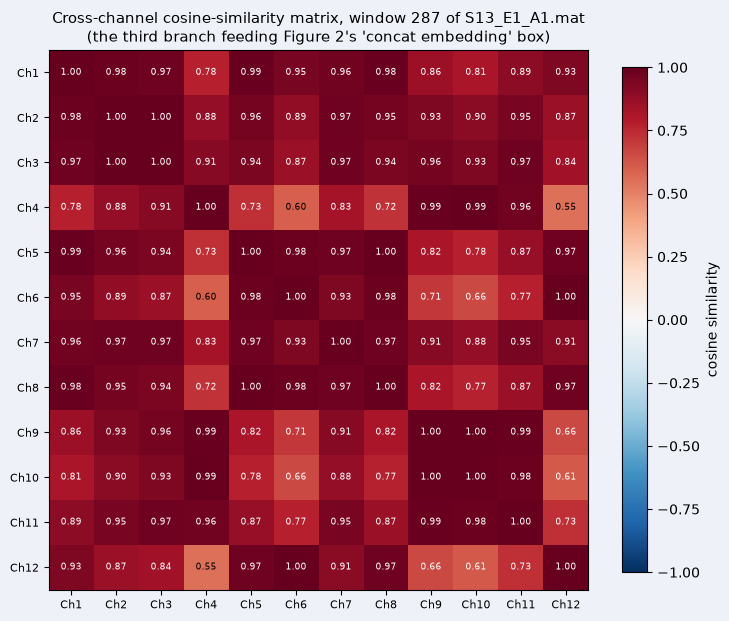

In [10]:
sim = b.channel_cosine_similarity(X[win_idx:win_idx + 1], M[win_idx:win_idx + 1])
sim_matrix = sim.reshape(ds["max_channels"], ds["max_channels"])[:n_real, :n_real]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(sim_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n_real)); ax.set_xticklabels([f"Ch{c+1}" for c in range(n_real)], fontsize=8)
ax.set_yticks(range(n_real)); ax.set_yticklabels([f"Ch{c+1}" for c in range(n_real)], fontsize=8)
for r in range(n_real):
    for c in range(n_real):
        ax.text(c, r, f"{sim_matrix[r, c]:.2f}", ha="center", va="center", fontsize=6.5,
               color="white" if abs(sim_matrix[r, c]) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="cosine similarity", shrink=0.85)
ax.set_title(f"Cross-channel cosine-similarity matrix, window {win_idx} of {SUBJECT_FILE}\n"
           "(the third branch feeding Figure 2's 'concat embedding' box)", fontsize=11)
plt.tight_layout()
plt.savefig("fig9_cosine_similarity_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 10 -- Cold vs. Calibrated: Why Calibration Matters

This project's central design decision: the base model trains on every available subject with no
held-out-subject split, and its "cold" (uncalibrated) accuracy is deliberately NOT the deliverable
-- per-subject calibration (`finetune()`) is. This figure makes that concrete: the SAME base
checkpoint's predictions, before and after calibrating to this subject, against the same true
values, for the same movement shown in Figures 1, 3 and 4 -- including two of the weakest joints
(J1, J2) so the comparison isn't cherry-picked to flatter calibration.

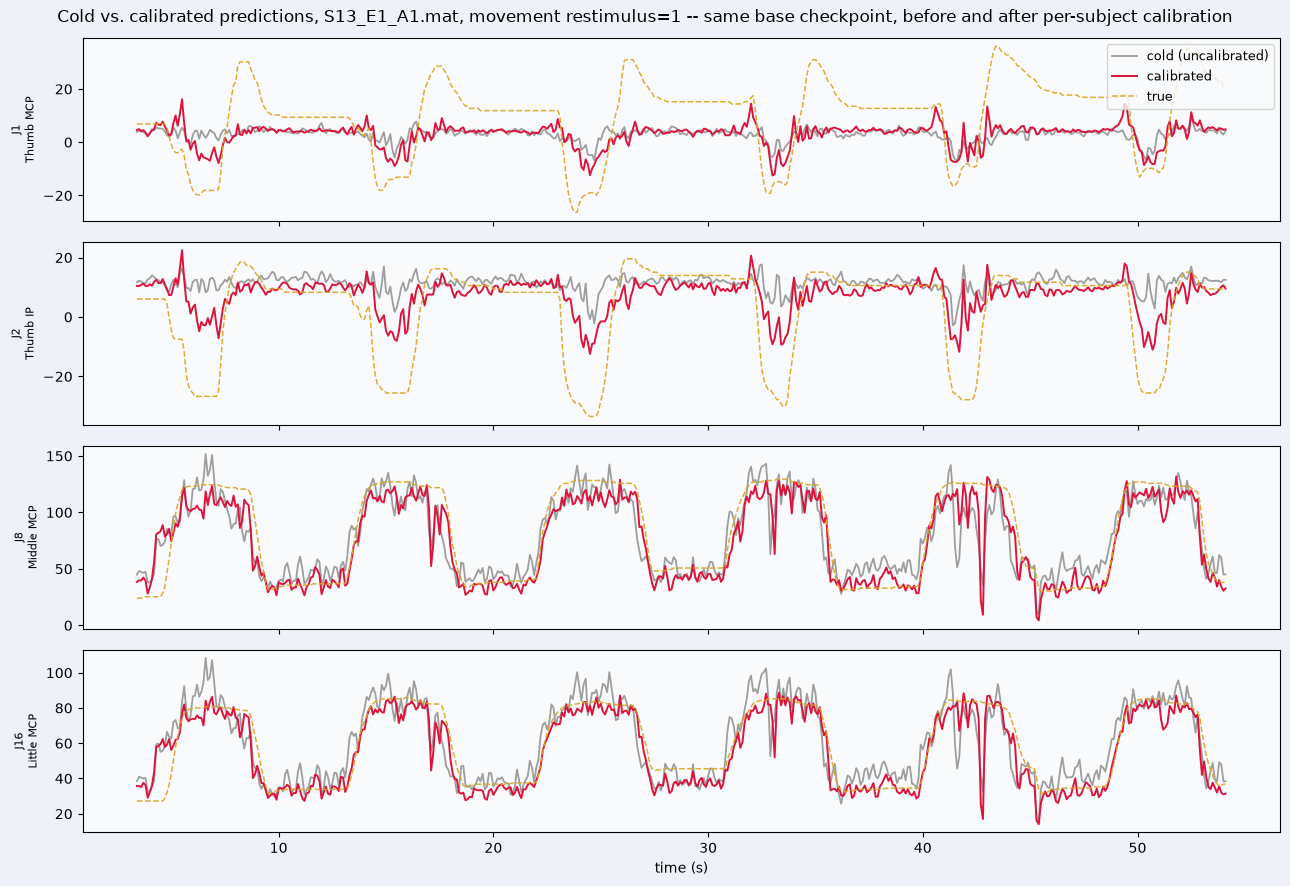

In [11]:
ckpt_prefix = ds["ckpt_prefix"]
base_ckpt_path = os.path.join(TEST9, f"{ckpt_prefix}.pt")
ck_cold = b.torch.load(base_ckpt_path, map_location=b.dev, weights_only=False)
net_cold = b.new_net(ds)
net_cold.load_state_dict(ck_cold["sd"]); net_cold.eval()
pred_cold = b.predict_batches(net_cold, ds, ck_cold, X, M)

show_joints = [1, 2, 8, 16]
seg_idx = np.arange(s0, s1 + 1)
tt_w = seg_idx * b.HOP / ds["fs"]

fig, axes = plt.subplots(len(show_joints), 1, figsize=(13, 9), sharex=True)
for ax, j in zip(axes, show_joints):
    ax.plot(tt_w, pred_cold[seg_idx, j], lw=1.3, color="#9e9e9e", label="cold (uncalibrated)")
    ax.plot(tt_w, pred[seg_idx, j], lw=1.4, color="crimson", label="calibrated")
    ax.plot(tt_w, Y[seg_idx, j], lw=1.1, color="goldenrod", ls="--", alpha=0.9, label="true")
    ax.set_ylabel(f"J{j}\n{JOINT_NAMES[j]}", fontsize=8)
axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"Cold vs. calibrated predictions, {SUBJECT_FILE}, movement restimulus={target_restim} -- "
           "same base checkpoint, before and after per-subject calibration", fontsize=12)
plt.tight_layout()
plt.savefig("fig10_cold_vs_calibrated.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 11 -- Inter-Subject Variability: Same Instructed Movement, Different Signals

The whole reason this project's design is calibration-first (Section 4.4 of the report) is that a
pooled model trained on many subjects does not generalise zero-shot to a new person. This figure
makes the underlying cause directly visible: Ninapro DB2's protocol assigns the SAME numeric
`restimulus` movement code to the SAME instructed movement for every subject, so `restimulus ==
target_restim` really is "the same activity" -- and yet both the raw EMG and the recorded
ground-truth kinematics for that identical instruction differ substantially between two real
subjects (S13 and S22, the same two subjects used throughout this project's calibration results).
This is not a modelling artifact -- it is measured directly from the raw recordings, no model
involved.

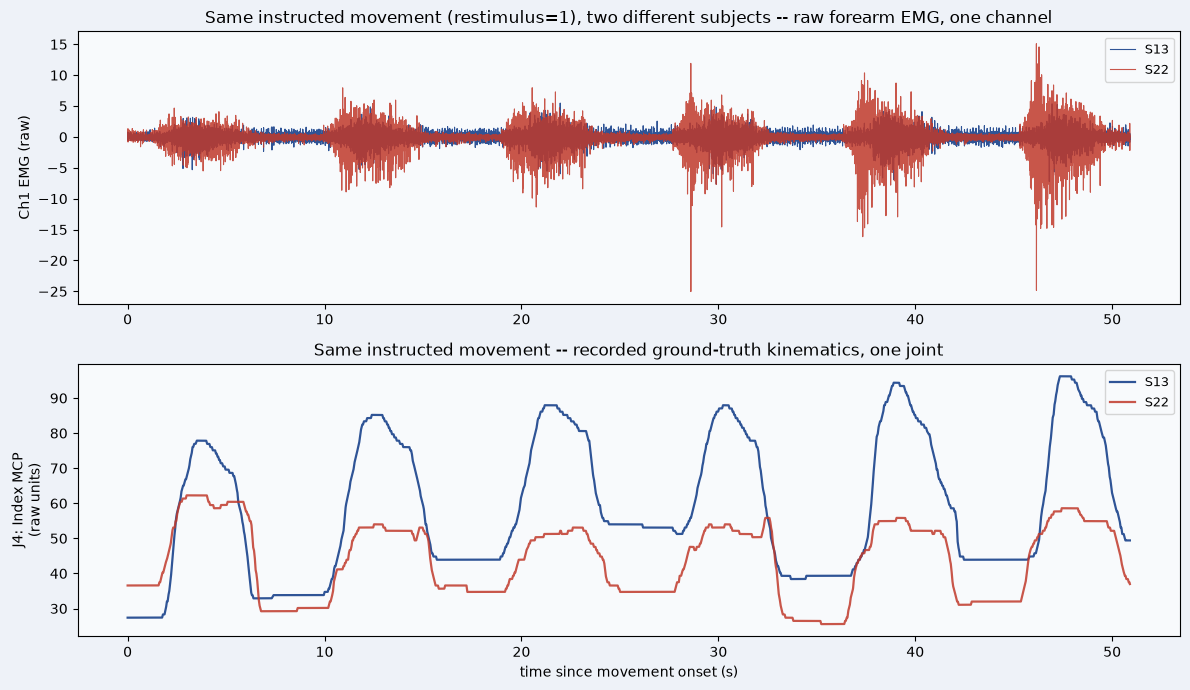

EMG RMS -- S13: 0.6068  |  S22: 1.3188  (ratio 2.17x)
J4 peak excursion from movement onset -- S13: 68.8  |  S22: 25.7  (ratio 2.68x)


In [12]:
SUBJECT_FILE_2 = "S22_E1_A1.mat"
data_path_2 = os.path.join(TEST9, "data", SUBJECT_FILE_2)

m2 = loadmat(data_path_2)
restim2 = m2["restimulus"].astype(int).ravel()
emg2, glove2, mask2, _ = b.load_emg_file(ds, data_path_2)
n_real2 = int(mask2.sum())
X2, Y2, M2, warns2 = b.windows_from(ds, data_path_2)
win_restim2 = np.asarray([np.bincount(restim2[s:s + b.WIN]).argmax()
                          for s in range(0, len(restim2) - b.WIN, b.HOP)])[:len(X2)]

# same movement code as Figures 1/3/4/5/10 (target_restim, found for S13) -- Ninapro DB2's
# Exercise protocol assigns the SAME numeric movement code to the SAME instructed movement for
# every subject, so restim==target_restim really is "the same activity" for both subjects
idx2 = np.where(win_restim2 == target_restim)[0]
s0_2, s1_2 = idx2[0], idx2[-1]

CH = 0          # first real EMG channel
JOINT = 4       # Index MCP -- matches Figure 3's show_joints

emg_t0_1, emg_t1_1 = s0 * b.HOP, s1 * b.HOP + b.WIN
emg_t0_2, emg_t1_2 = s0_2 * b.HOP, s1_2 * b.HOP + b.WIN
emg1_seg = emg[emg_t0_1:emg_t1_1, CH]
emg2_seg = emg2[emg_t0_2:emg_t1_2, CH]
tt1 = np.arange(len(emg1_seg)) / ds["fs"]
tt2 = np.arange(len(emg2_seg)) / ds["fs"]

kin1_seg = glove[emg_t0_1:emg_t1_1, JOINT]
kin2_seg = glove2[emg_t0_2:emg_t1_2, JOINT]

subj1, subj2 = SUBJECT_FILE.split("_")[0], SUBJECT_FILE_2.split("_")[0]

fig, (axA, axB) = plt.subplots(2, 1, figsize=(12, 7))
axA.plot(tt1, emg1_seg, lw=0.8, color="#2F5496", label=subj1)
axA.plot(tt2, emg2_seg, lw=0.8, color="#c0392b", alpha=0.85, label=subj2)
axA.set_ylabel(f"Ch{CH+1} EMG (raw)")
axA.set_title(f"Same instructed movement (restimulus={target_restim}), two different subjects -- "
             "raw forearm EMG, one channel")
axA.legend(fontsize=9)

axB.plot(tt1, kin1_seg, lw=1.6, color="#2F5496", label=subj1)
axB.plot(tt2, kin2_seg, lw=1.6, color="#c0392b", alpha=0.85, label=subj2)
axB.set_ylabel(f"J{JOINT}: {JOINT_NAMES[JOINT]}\n(raw units)")
axB.set_xlabel("time since movement onset (s)")
axB.set_title("Same instructed movement -- recorded ground-truth kinematics, one joint")
axB.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig11_inter_subject_variability.png", dpi=150, bbox_inches="tight")
plt.show()

emg1_rms, emg2_rms = float(np.sqrt(np.mean(emg1_seg**2))), float(np.sqrt(np.mean(emg2_seg**2)))
kin1_peak = float(np.max(np.abs(kin1_seg - kin1_seg[0])))
kin2_peak = float(np.max(np.abs(kin2_seg - kin2_seg[0])))
print(f"EMG RMS -- {subj1}: {emg1_rms:.4f}  |  {subj2}: {emg2_rms:.4f}  "
     f"(ratio {max(emg1_rms, emg2_rms) / min(emg1_rms, emg2_rms):.2f}x)")
print(f"J{JOINT} peak excursion from movement onset -- {subj1}: {kin1_peak:.1f}  |  "
     f"{subj2}: {kin2_peak:.1f}  (ratio {max(kin1_peak, kin2_peak) / min(kin1_peak, kin2_peak):.2f}x)")


## Figure 12 -- Inter-Subject Variability Across All Subjects, Same Movement

A clearer version of the same check as Figure 11, scaled up: every available DB2 subject (19
recordings) performing the exact same instructed movement (`restimulus=1`, identical to Figure 11),
as two sorted bar charts -- one subject per bar, one bar per subject, ranked from highest to lowest.
No box-plot statistics to read, no overlapping lines -- just the same raw, un-modelled measurement
(EMG RMS on one channel, kinematics peak-to-peak range on one joint) directly compared, subject by
subject, for the identical instruction.

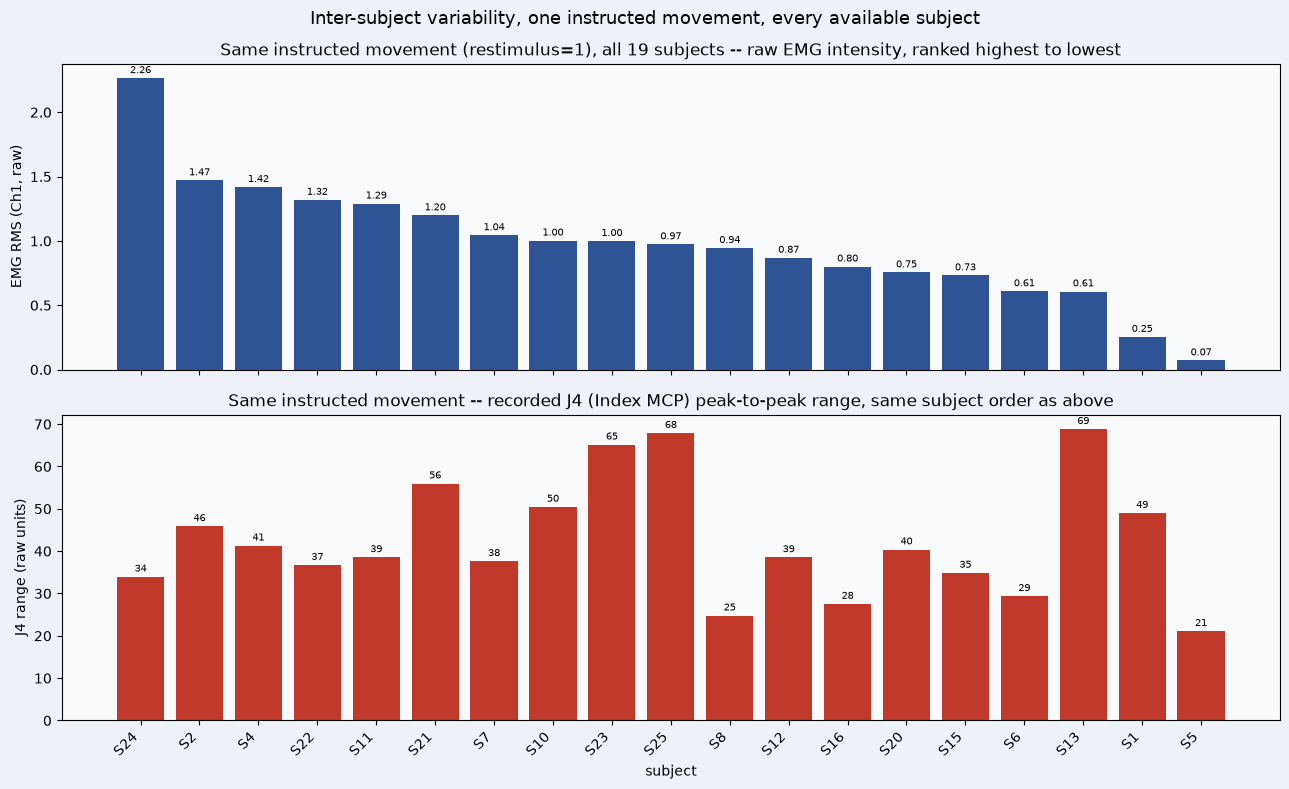

EMG RMS -- highest: S24 (2.26), lowest: S5 (0.07), ratio 31.9x
J4 range -- highest: 69, lowest: 21, ratio 3.3x


In [13]:
import glob

MOVEMENT = 1   # same instructed movement as Figure 11 (S13 vs. S22)
CH = 0
JOINT = 4
all_files = sorted(glob.glob(os.path.join(TEST9, "data", "S*_E1_A1.mat")) +
                   glob.glob(os.path.join(TEST9, "data", "S*_A1_E1.mat")))

rows = []
for f in all_files:
    subj = os.path.basename(f).split("_")[0]
    mm = loadmat(f)
    restim_f = mm["restimulus"].astype(int).ravel()
    emg_f, glove_f, mask_f, _ = b.load_emg_file(ds, f)
    Xf, Yf, Mf, _ = b.windows_from(ds, f)
    win_restim_f = np.asarray([np.bincount(restim_f[s:s + b.WIN]).argmax()
                               for s in range(0, len(restim_f) - b.WIN, b.HOP)])[:len(Xf)]
    idxs = np.where(win_restim_f == MOVEMENT)[0]
    if len(idxs) < 15:
        print(f"skipping {subj}: only {len(idxs)} windows for restim={MOVEMENT}")
        continue
    t0, t1 = idxs[0] * b.HOP, idxs[-1] * b.HOP + b.WIN
    emg_seg = emg_f[t0:t1, CH]
    kin_seg = glove_f[t0:t1, JOINT]
    rows.append((subj, float(np.sqrt(np.mean(emg_seg ** 2))), float(kin_seg.max() - kin_seg.min())))

# order both panels by EMG RMS (descending) so the SAME subject sits at the SAME x-position in
# both charts -- makes it easy to see whether "loud EMG" subjects are also "big kinematics range"
# subjects, or not
rows.sort(key=lambda r: -r[1])
subjects = [r[0] for r in rows]
emg_vals = [r[1] for r in rows]
kin_vals = [r[2] for r in rows]

fig, (axA, axB) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

barsA = axA.bar(subjects, emg_vals, color="#2F5496")
axA.set_ylabel("EMG RMS (Ch1, raw)")
axA.set_title(f"Same instructed movement (restimulus={MOVEMENT}), all {len(subjects)} subjects -- "
             "raw EMG intensity, ranked highest to lowest")
axA.bar_label(barsA, fmt="%.2f", fontsize=7, padding=2)

barsB = axB.bar(subjects, kin_vals, color="#c0392b")
axB.set_ylabel(f"J{JOINT} range (raw units)")
axB.set_xlabel("subject")
axB.set_title(f"Same instructed movement -- recorded J{JOINT} ({JOINT_NAMES[JOINT]}) peak-to-peak "
             "range, same subject order as above")
axB.bar_label(barsB, fmt="%.0f", fontsize=7, padding=2)
plt.setp(axB.get_xticklabels(), rotation=45, ha="right")

fig.suptitle("Inter-subject variability, one instructed movement, every available subject", fontsize=13)
plt.tight_layout()
plt.savefig("fig12_inter_subject_variability_all_subjects.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"EMG RMS -- highest: {subjects[0]} ({emg_vals[0]:.2f}), lowest: {subjects[-1]} ({emg_vals[-1]:.2f}), "
     f"ratio {emg_vals[0] / emg_vals[-1]:.1f}x")
kin_sorted = sorted(kin_vals)
print(f"J{JOINT} range -- highest: {kin_sorted[-1]:.0f}, lowest: {kin_sorted[0]:.0f}, "
     f"ratio {kin_sorted[-1] / kin_sorted[0]:.1f}x")
